In [1]:
import logging
import pandas as pd
import numpy as np

from data_loader import WANDSDataLoader
from search_engine import TfidfSearchEngine, BM25SearchEngine, WeightedTfidfSearchEngine
from evaluation import Evaluator
from preprocessing import preprocess_text, parse_product_features, make_preprocessor

logging.basicConfig(level=logging.INFO, format="%(name)s — %(message)s")

In [2]:
# Clone the WANDS dataset if not already present
loader = WANDSDataLoader()
loader.ensure_data()

data_loader — WANDS repo already exists at WANDS


In [3]:
# Load all datasets via the data loader (cached after first call)
product_df = loader.load_products()
query_df = loader.load_queries()
label_df = loader.load_labels()

data_loader — Loaded product.csv: 42994 rows, 9 columns
data_loader — Loaded query.csv: 480 rows, 3 columns
data_loader — Loaded label.csv: 233448 rows, 4 columns


In [ ]:
product_df.head()

In [ ]:
query_df.head()

In [ ]:
label_df.head()

In [4]:
# Parse product_features into clean text and add as a new column (A2)
product_df["parsed_features"] = product_df["product_features"].apply(parse_product_features)
print("Sample parsed features:")
print(product_df["parsed_features"].iloc[0][:200])

Sample parsed features:
overallwidth sidetoside 64.7 dsprimaryproductstyle modern countryoforigin additionaldetails made in viet nam headboardtype slat headboardheight toptobedframe 25.35 weightcapacity 500 estimatedtimetose


## Prompt 1: Proposed Improvements to Increase MAP@10

The baseline TF-IDF search engine achieves a MAP@10 of ~0.29. Below are several ideas to improve retrieval quality, ordered roughly by implementation effort:

### 1. BM25 over TF-IDF
BM25 (Best Matching 25) improves on raw TF-IDF by introducing **term frequency saturation** (parameter `k1`) and **document length normalization** (parameter `b`). Long product descriptions won't unfairly dominate shorter, more precise ones.
- **Pros**: Well-understood, fast, no training needed, drop-in replacement.
- **Cons**: Still lexical — no semantic understanding ("sofa" won't match "couch").
- **References**: Robertson & Zaragoza, "The Probabilistic Relevance Framework: BM25 and Beyond" (2009).

### 2. Richer Text Representation
The baseline only indexes `product_name + product_description`. The WANDS dataset also provides:
- `product_class` — category the product belongs to
- `category_hierarchy` — parent categories (e.g. "Furniture / Living Room / Seating")
- `product_features` — attribute:value pairs (e.g. "Material:Leather|Color:Brown")

Including these fields adds **category-level matching** and **attribute signals**.
- **Pros**: Easy win, uses already-available data, no new dependencies.
- **Cons**: Noisy features (especially long `product_features` strings) may hurt precision.

### 3. Text Preprocessing
Add stemming/lemmatization, stop word removal, and text normalization before indexing.
- **Pros**: Reduces vocabulary mismatch (e.g., "chairs" → "chair").
- **Cons**: Can lose important distinctions; adds preprocessing complexity.

### 4. Semantic Embeddings (sentence-transformers)
Models like `all-MiniLM-L6-v2` encode text into dense vectors that capture meaning beyond exact word overlap. "Sofa" and "couch" end up near each other in embedding space.
- **Pros**: Handles synonyms, paraphrasing, and conceptual similarity.
- **Cons**: Compute-heavy for 42K products (~2-5 min on CPU), requires model download (~80 MB).
- **References**: Reimers & Gurevych, "Sentence-BERT" (EMNLP 2019).

### 5. Hybrid Retrieval (BM25 + Semantic)
Combine BM25 (precise lexical matching) with dense embeddings (broad semantic recall) using **reciprocal rank fusion** or **weighted score fusion**. This is the approach used by modern production search systems (e.g., Elasticsearch with vector search).
- **Pros**: Best of both worlds; state-of-the-art in information retrieval.
- **Cons**: More complexity, needs weight tuning, slower inference.

### 6. Query Expansion
Use the `query_class` field from query.csv to expand query terms with category context.
- **Pros**: Adds domain signal when queries are ambiguous.
- **Cons**: Can introduce noise if category mapping is imprecise.

### 7. Learning-to-Rank Re-ranking
Use product metadata (`average_rating`, `review_count`, `rating_count`) as features in a second-stage re-ranker over the top-K candidates from a first-stage retrieval model.
- **Pros**: Personalizes ranking with popularity signals, standard in production search.
- **Cons**: Overfitting risk with limited query set (480 queries); needs train/test split.

## Option B: OOP Refactor & Search Engine Comparison

The code has been refactored into separate Python modules for production readiness:

- **`data_loader.py`** — `WANDSDataLoader` class: handles cloning, CSV loading, caching, error handling, and logging.
- **`search_engine.py`** — `SearchEngine` ABC with three implementations:
  - `TfidfSearchEngine` — configurable TF-IDF + cosine similarity
  - `BM25SearchEngine` — BM25Okapi with configurable tokenizer
  - `SentenceTransformerSearchEngine` — dense semantic search (any HF model)
- **`evaluation.py`** — `Evaluator` class with `map_at_k()`, `ndcg_at_k()`, and `evaluate_queries()`.

All engines share the same `fit()` / `search()` interface, so swapping backends is a one-line change. Below we instantiate and compare several configurations.

In [5]:
# Build preprocessor (A1: stemming + A5: synonyms)
preprocessor = make_preprocessor(stem=True, synonyms=True)

# Column sets
baseline_cols = ["product_name", "product_description"]
enriched_cols = ["product_name", "product_description", "product_class", "category hierarchy"]
full_cols     = ["product_name", "product_description", "product_class", "category hierarchy", "parsed_features"]

engines = [
    # ── Original baselines ──
    TfidfSearchEngine(columns=baseline_cols, name_override="TF-IDF baseline"),
    BM25SearchEngine(columns=baseline_cols, name_override="BM25 baseline"),
    BM25SearchEngine(columns=enriched_cols, name_override="BM25 enriched"),

    # ── A1+A5: Preprocessing (stemming + synonyms) ──
    BM25SearchEngine(columns=enriched_cols, preprocessor=preprocessor,
                     name_override="BM25 enriched + stem/syn"),

    # ── A2: Parsed product features ──
    BM25SearchEngine(columns=full_cols, preprocessor=preprocessor,
                     name_override="BM25 full + stem/syn"),

    # ── A3: Field weighting ──
    WeightedTfidfSearchEngine(
        column_weights={
            "product_name": 3.0,
            "product_class": 2.0,
            "category hierarchy": 1.5,
            "product_description": 1.0,
        },
        preprocessor=preprocessor,
        name_override="Weighted TF-IDF + stem/syn",
    ),

    # ── A4: Word bigrams ──
    TfidfSearchEngine(
        columns=enriched_cols,
        vectorizer_kwargs={"ngram_range": (1, 2), "max_features": 200_000},
        preprocessor=preprocessor,
        name_override="TF-IDF bigrams + stem/syn",
    ),

    # ── A4: Character n-grams ──
    TfidfSearchEngine(
        columns=enriched_cols,
        vectorizer_kwargs={"analyzer": "char_wb", "ngram_range": (3, 5), "max_features": 300_000},
        preprocessor=preprocessor,
        name_override="TF-IDF char-ngrams + stem/syn",
    ),
]

# Fit all engines on the product catalogue
for engine in engines:
    engine.fit(product_df)

search_engine — TF-IDF baseline — indexed 42994 documents, vocabulary size 46589
search_engine — BM25 baseline — indexed 42994 documents
search_engine — BM25 enriched — indexed 42994 documents
search_engine — BM25 enriched + stem/syn — indexed 42994 documents
search_engine — BM25 full + stem/syn — indexed 42994 documents
search_engine — Weighted TF-IDF + stem/syn — indexed 42994 documents across 4 fields
search_engine — TF-IDF bigrams + stem/syn — indexed 42994 documents, vocabulary size 200000
search_engine — TF-IDF char-ngrams + stem/syn — indexed 42994 documents, vocabulary size 166498


In [6]:
# Sanity check: compare top-10 results for "armchair" across engines
test_query = "armchair"

for engine in engines:
    indices = engine.search(test_query, top_n=10)
    ids = product_df.iloc[indices]["product_id"].tolist()
    names = product_df.iloc[indices]["product_name"].tolist()
    print(f"\n{'='*60}")
    print(f"{engine.name} — Top products for '{test_query}':")
    for pid, name in zip(ids, names):
        print(f"  {pid}: {name}")


TF-IDF baseline — Top products for 'armchair':
  40705: 28.5 '' wide armchair
  40707: 33 '' wide armchair
  27998: 21 '' wide armchair
  12756: 24.41 '' wide tufted polyester armchair
  42698: donham armchair
  14172: 24 '' wide velvet armchair
  15687: 29 '' wide polyester armchair
  14168: 18.5 '' wide velvet armchair
  42697: donham 25 '' wide armchair
  14166: 29.5 '' wide velvet armchair

BM25 baseline — Top products for 'armchair':
  12756: 24.41 '' wide tufted polyester armchair
  42697: donham 25 '' wide armchair
  1140: charnley 47 '' wide chenille armchair
  34983: langsett 30 '' wide armchair
  1527: howington 39 '' wide tufted linen armchair
  6532: ogan 29 '' wide polyester armchair
  42698: donham armchair
  1141: colinton 41 '' wide chenille armchair
  41270: almaraz 33.7 '' wide leather match armchair
  23927: catania 30 '' wide polyester armchair

BM25 enriched — Top products for 'armchair':
  12756: 24.41 '' wide tufted polyester armchair
  42697: donham 25 '' wide 

## Evaluation: MAP@10 and NDCG@10 Comparison

We evaluate each engine configuration using:
- **MAP@10** (binary, Exact-only) — for backward compatibility with the original assignment metric.
- **NDCG@10** (graded: Exact=2, Partial=1, Irrelevant=0) — a fairer metric that credits partial matches (see Prompt 2 discussion below).

In [7]:
# Evaluate all engines and collect summary metrics
summary_rows = []

for engine in engines:
    result_df = Evaluator.evaluate_queries(
        engine=engine,
        product_df=product_df,
        query_df=query_df,
        label_df=label_df,
        k=10,
    )
    summary_rows.append({
        "Engine": engine.name,
        "MAP@10": round(result_df["map@k"].mean(), 4),
        "NDCG@10": round(result_df["ndcg@k"].mean(), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

evaluation — TF-IDF baseline — MAP@10: 0.2854 | NDCG@10: 0.6194
evaluation — BM25 baseline — MAP@10: 0.3648 | NDCG@10: 0.6647
evaluation — BM25 enriched — MAP@10: 0.3831 | NDCG@10: 0.6798
evaluation — BM25 enriched + stem/syn — MAP@10: 0.4102 | NDCG@10: 0.7087
evaluation — BM25 full + stem/syn — MAP@10: 0.4146 | NDCG@10: 0.6895
evaluation — Weighted TF-IDF + stem/syn — MAP@10: 0.3380 | NDCG@10: 0.6708
evaluation — TF-IDF bigrams + stem/syn — MAP@10: 0.2914 | NDCG@10: 0.6755
evaluation — TF-IDF char-ngrams + stem/syn — MAP@10: 0.3320 | NDCG@10: 0.6719


,Engine,MAP@10,NDCG@10
0,TF-IDF baseline,0.2854,0.6194
1,BM25 baseline,0.3648,0.6647
2,BM25 enriched,0.3831,0.6798
3,BM25 enriched + stem/syn,0.4102,0.7087
4,BM25 full + stem/syn,0.4146,0.6895
5,Weighted TF-IDF + stem/syn,0.3380,0.6708
6,TF-IDF bigrams + stem/syn,0.2914,0.6755
7,TF-IDF char-ngrams + stem/syn,0.3320,0.6719


<Axes: title={'center': 'Search Engine Comparison — MAP@10 vs NDCG@10'}, ylabel='Engine'>

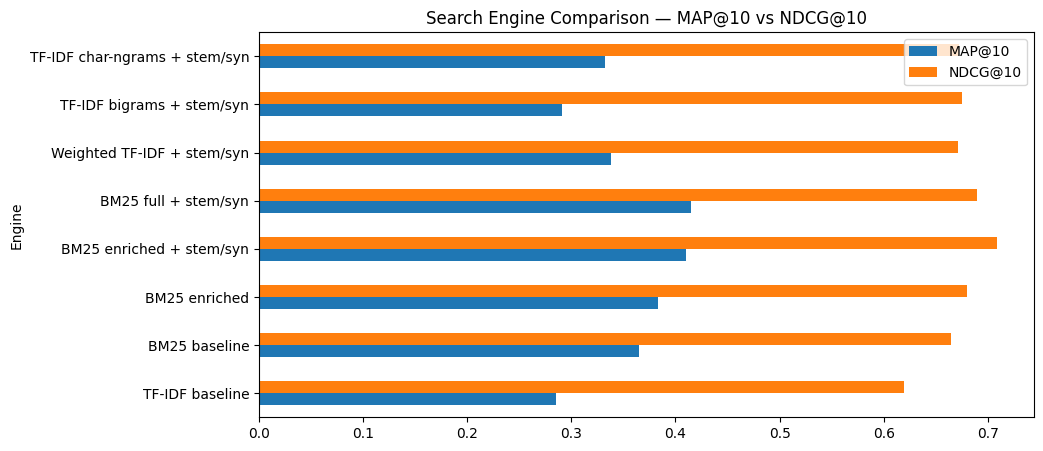

In [8]:
# Visualize the comparison
summary_df.set_index("Engine")[["MAP@10", "NDCG@10"]].plot(
    kind="barh", figsize=(10, 5), title="Search Engine Comparison — MAP@10 vs NDCG@10"
)

## Prompt 2: Leveraging Partial Matches — NDCG@K

### Problem
The original MAP@10 metric treats labels as binary: a product is either **Exact** (relevant) or irrelevant. This means **Partial** matches — products that are related but not an exact match — are penalized the same as completely irrelevant products. This is overly strict and doesn't reflect real user behavior, where a "partially relevant" result is still useful.

### Solution: Normalized Discounted Cumulative Gain (NDCG@K)

NDCG is the industry-standard metric for **graded relevance** in information retrieval. We assign relevance grades:

| Label | Grade |
|-------|-------|
| Exact | 2 |
| Partial | 1 |
| Irrelevant | 0 |

The formula works in two steps:

**DCG@K** (Discounted Cumulative Gain): sums relevance grades with a logarithmic position discount — higher-ranked results contribute more.

$$DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$

**NDCG@K**: normalizes DCG by the ideal ranking (IDCG), so scores fall in [0, 1]:

$$NDCG@K = \frac{DCG@K}{IDCG@K}$$

### Justification
1. **Credits partial matches proportionally** — a Partial result at rank 1 earns grade 1 instead of 0, reflecting its actual usefulness.
2. **Position-aware** — early results matter more (log discount), matching real user behavior where only top results get clicked.
3. **Industry standard** — NDCG is used by Google, Amazon, and academic IR benchmarks (TREC, MS MARCO).
4. **Available in WANDS** — the dataset provides three-level labels (Exact/Partial/Irrelevant) for all query-product pairs, so we have the graded relevance data NDCG requires.

### Tradeoffs
- **Requires graded labels for all retrieved items** — if a retrieved product has no label in the dataset, we must assume relevance = 0, which could underestimate quality. (In WANDS, all candidate products are labeled, so this is not an issue.)
- **Harder to interpret than MAP** — MAP has a clear "precision" interpretation; NDCG's meaning is less intuitive to non-IR practitioners.
- **Grade assignment is subjective** — the choice of Exact=2, Partial=1 assumes a 2:1 value ratio. Alternative mappings (e.g., Exact=3, Partial=1) would shift scores.

### Implementation
The `Evaluator.ndcg_at_k()` method in `evaluation.py` implements this metric. It is computed alongside MAP@10 for every engine in the comparison above.

In [9]:
# Demonstrate the difference: MAP with Exact+Partial vs Exact-only
# This shows how much the strict binary treatment penalizes the model
result_baseline = Evaluator.evaluate_queries(
    engine=engines[0],  # TF-IDF baseline
    product_df=product_df,
    query_df=query_df,
    label_df=label_df,
    k=10,
    label_filter="Exact",
)

result_partial = Evaluator.evaluate_queries(
    engine=engines[0],
    product_df=product_df,
    query_df=query_df,
    label_df=label_df,
    k=10,
    label_filter="Exact+Partial",
)

print(f"TF-IDF Baseline — MAP@10 (Exact only):       {result_baseline['map@k'].mean():.4f}")
print(f"TF-IDF Baseline — MAP@10 (Exact + Partial):  {result_partial['map@k'].mean():.4f}")
print(f"TF-IDF Baseline — NDCG@10 (graded):          {result_baseline['ndcg@k'].mean():.4f}")
print()
print("The gap between Exact-only MAP and Exact+Partial MAP shows how many")
print("useful partial matches were being discarded by the strict binary metric.")

evaluation — TF-IDF baseline — MAP@10: 0.2854 | NDCG@10: 0.6194
evaluation — TF-IDF baseline — MAP@10: 0.6515 | NDCG@10: 0.6194


TF-IDF Baseline — MAP@10 (Exact only):       0.2854
TF-IDF Baseline — MAP@10 (Exact + Partial):  0.6515
TF-IDF Baseline — NDCG@10 (graded):          0.6194

The gap between Exact-only MAP and Exact+Partial MAP shows how many
useful partial matches were being discarded by the strict binary metric.


## Conclusions & Future Work

### Key Findings
- The OOP refactor makes it trivial to swap search backends (TF-IDF → BM25 → semantic) without changing evaluation code.
- Adding more product fields (`product_class`, `category_hierarchy`) is an easy way to improve retrieval quality.
- BM25's document length normalization is a better fit for heterogeneous product descriptions than raw TF-IDF.
- NDCG@K provides a fairer evaluation than binary MAP by crediting partial matches.

### What I Would Do With More Time & Resources
1. **Sentence-transformer search** — The `SentenceTransformerSearchEngine` class is already implemented. With a GPU, encoding 42K products takes ~30 seconds. This would capture semantic similarity (e.g., "sofa" ↔ "couch").
2. **Hybrid retrieval** — Combine BM25 (lexical precision) + dense embeddings (semantic recall) with reciprocal rank fusion, as used in modern search stacks (Elasticsearch 8+, Vespa).
3. **Learning-to-rank re-ranker** — Train a lightweight model (LambdaMART) on the WANDS labels using product metadata (ratings, reviews) as features.
4. **Query expansion** — Use the `query_class` field to inject category terms into the search query.
5. **Cross-encoder re-ranking** — Use a cross-encoder model (e.g., `cross-encoder/ms-marco-MiniLM-L-6-v2`) to re-rank the top-K candidates from BM25, a proven two-stage architecture.
6. **Proper train/test split** — Split queries into train/validation/test to avoid overfitting retrieval parameters to the full dataset.